**PR0206: Ingesta de datos financieros en InfluxDB**

En esta práctica vamos a crear un un agente de ingestión en Python que lea múltiples ficheros CSV de cotizaciones, los procese y los almacene de manera eficiente en un Bucket de InfluxDB, aplicando el modelo de datos correcto (Tags y Fields).

Para ello vamos a trabajar con el dataset Cryptocurrency Historical Prices de Kaggle, que contiene datos sobre la evolución de precios de 23 criptomonedas entre los años 2017 y 2021.

In [1]:
import os
import csv
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import ASYNCHRONOUS, WriteOptions

DATA_DIR = "data/crypto_files/"
INFLUX_URL = "http://influxdb2:8086"
INFLUX_TOKEN = "MyInitialAdminToken0="
INFLUX_ORG = "docs"
BUCKET = "crypto_raw"

puntos_insertados = 0

client = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
write_api = client.write_api(write_options=WriteOptions(write_type=ASYNCHRONOUS, batch_size=5000))

def procesar_fichero(filepath):
    global puntos_insertados
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            name      = row[1]
            symbol    = row[2]
            date_str  = row[3]
            high      = float(row[4])
            low       = float(row[5])
            open_     = float(row[6])
            close     = float(row[7])
            volume    = float(row[8])
            marketcap = float(row[9])
            fecha = datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S")
            fecha_utc= fecha.replace(tzinfo=timezone.utc)
            #Pasamos a ISO 8602
            time_date = fecha_utc.isoformat().replace('+00:00','Z')
            p = (
                Point("daily_quote")
                .tag("symbol", symbol)
                .tag("name", name)
                .time(fecha, WritePrecision.NS)
                .field("close", float(close))
                .field("high", float(high))
                .field("low", float(low))
                .field("open", float(open_))
                .field("volume", float(volume))
                .field("marketcap", float(marketcap))
            )
            write_api.write(bucket=BUCKET, record=p)
            puntos_insertados += 1
    print(f"Fichero {os.path.basename(filepath)} procesado.")

def main():
    for fichero in os.listdir(DATA_DIR):
        if fichero.endswith(".csv"):
            procesar_fichero(os.path.join(DATA_DIR, fichero))
    write_api.close()
    print(f"Ingesta finalizada. Total puntos insertados: {puntos_insertados}")

if __name__ == "__main__":
    main()


Fichero coin_Aave.csv procesado.
Fichero coin_BinanceCoin.csv procesado.
Fichero coin_Bitcoin.csv procesado.
Fichero coin_Cardano.csv procesado.
Fichero coin_ChainLink.csv procesado.
Fichero coin_Cosmos.csv procesado.
Fichero coin_CryptocomCoin.csv procesado.
Fichero coin_Dogecoin.csv procesado.
Fichero coin_EOS.csv procesado.
Fichero coin_Ethereum.csv procesado.
Fichero coin_Iota.csv procesado.
Fichero coin_Litecoin.csv procesado.
Fichero coin_Monero.csv procesado.
Fichero coin_NEM.csv procesado.
Fichero coin_Polkadot.csv procesado.
Fichero coin_Solana.csv procesado.
Fichero coin_Stellar.csv procesado.
Fichero coin_Tether.csv procesado.
Fichero coin_Tron.csv procesado.
Fichero coin_Uniswap.csv procesado.
Fichero coin_USDCoin.csv procesado.
Fichero coin_WrappedBitcoin.csv procesado.
Fichero coin_XRP.csv procesado.
Ingesta finalizada. Total puntos insertados: 37082


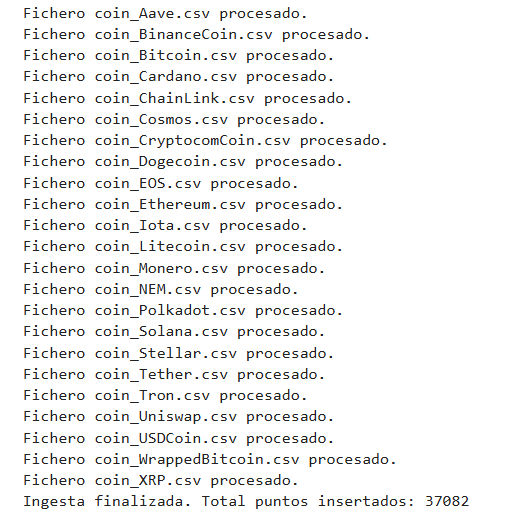